In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset_path = os.path.join("dataset.xlsx")
dataset = pd.read_excel(dataset_path, header=0)
features = dataset.drop('churn', axis=1).to_numpy()
labels = dataset['churn'].to_numpy()

In [3]:
def normalization(x):
    max_ = np.max(x)
    min_ = np.min(x)
    
    output = np.zeros(x.shape)
    for i in range(len(output)):
        output[i] = (x[i] - min_)/(max_ - min_)
    return(output)

In [4]:
normal_features = np.zeros(features.shape)
for i in range(features.shape[1]):
    normal_features[:,i] = normalization(features[:,i])

In [5]:
class LogisticRegression:
    
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.weights = np.random.random(self.x.shape[1])
        self.bias = np.random.random() * 1e-3
    
    def sigmoid(self, z):
        y_hat = 1 / (1 + (np.exp(-z)))
        return(y_hat)
    
    def bce(self, y_hat):
        loss = -np.mean((self.y * np.log(y_hat)) + ((1 - self.y) * np.log(1 - y_hat)))
        return(loss)
    
    def gradient(self, y_hat):
        grad_w = np.dot(self.x.T, (y_hat - self.y)) / len(self.y)
        grad_b = np.mean((y_hat - self.y))
        return(grad_w, grad_b)
    
    def forward(self):
        z = np.dot(self.x, self.weights) + self.bias
        y_hat = self.sigmoid(z)
        return(y_hat)
    
    def train(self, lr):
        y_hat = self.forward()
        loss = self.bce(y_hat)
        grad_w, grad_b = self.gradient(y_hat)
        self.weights -= lr * grad_w
        self.bias -= lr * grad_b
        return(y_hat, loss)
    
    def predict(self, x):
        z = np.dot(x, self.weights) + self.bias
        y_hat = self.sigmoid(z)
        return (y_hat >= 0.5).astype(int)

In [6]:
def acc(y_true, y_pred):
    output = np.mean(y_true == y_pred)
    return(output)

In [7]:
model = LogisticRegression(normal_features, labels)
epochs = 100
accuracy = np.zeros(epochs)
losses = np.zeros(epochs)
for i in range(epochs):
    y_hat, losses[i] = model.train(lr=6e-1)
    y_pred = model.predict(normal_features)
    accuracy[i] = acc(labels, y_pred)

pred = model.predict(normal_features[4])

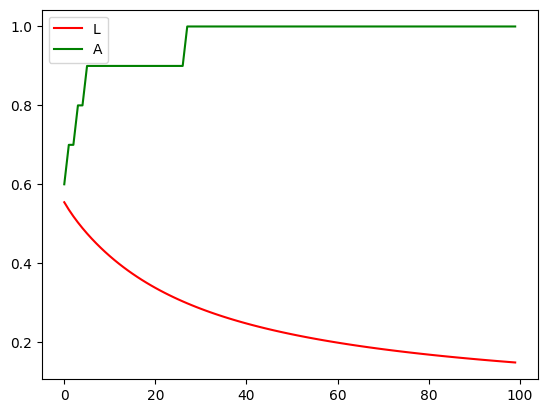

In [8]:
plt.plot(range(epochs), losses, c='red')
plt.plot(range(epochs), accuracy, c='green')
plt.legend("LA")
plt.show()